In [4]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pyref.fitting as fit

from utils import models_root

In [2]:
# with open(models_root / "xrr/free/free_en_offset_init_2.pkl", "rb") as f:
#     free_objective = pickle.load(f)

with open(models_root / "xrr/old/fitting_results_fixed_2.pkl", "rb") as f:
    dft_constraint = pickle.load(f)

In [3]:
thicknesses = [np.float64(0.0),
  np.float64(9.988515233890404),
  np.float64(180.55434666973406),
  np.float64(11.003133679531317),
  np.float64(8.837167307453562),
  np.float64(0.0)]
roughnesses = [np.float64(0.0),
  np.float64(6.220174471477204),
  np.float64(12.301979543127507),
  np.float64(7.533760864640265),
  np.float64(5.092155307950688),
  np.float64(1.2)]

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/refnx/analysis/curvefitter.py:847: OptimizeWarning: Unknown solver options: worker
  res = minimize(cost, init_pars, **_min_kws)
-0.9752038518835309: : 634it [02:10,  4.85it/s] 


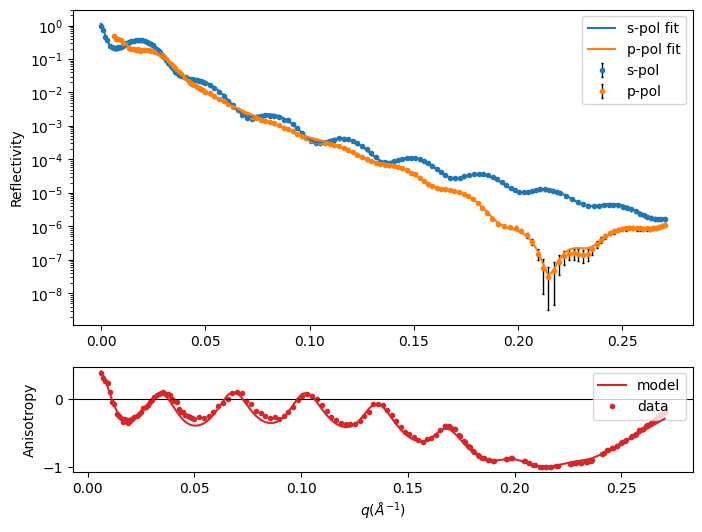

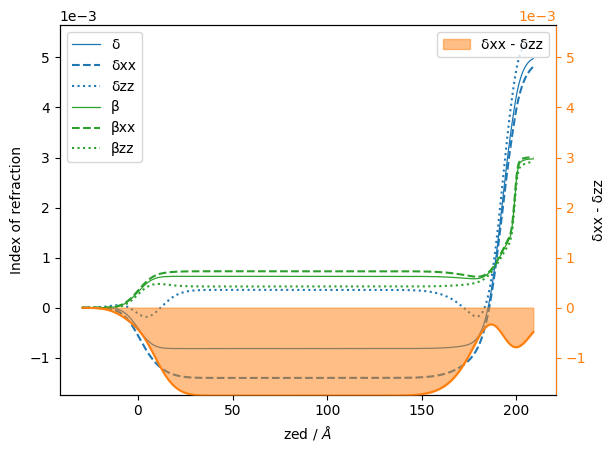

________________________________________________________________________________
Structure: Monolayer_283.7
reverse structure: False
________________________________________________________________________________
Parameters: 'Vacuum_283.7' 
________________________________________________________________________________
Parameters: 'Vacuum_283.7_slab'
<Parameter:'Vacuum_283.7_thick', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rough', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rho', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_energy_offset', value=-0.0675529 +/- 1.99e-06, bounds=[-0.5, 0.5], constraint=<Parameter:'energy_offset', value=-0.0675529 +/- 1.99e-06, bounds=[-0.5, 0.5]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'Surface_283.7_th

In [5]:
def interface_bounds(interface):
    interface.thick.setp(vary=True, value = thicknesses[3])
    interface.rough.setp(vary=True, value = roughnesses[3])

def bulk_bounds(bulk):
    bulk.thick.setp(vary=True, value = thicknesses[2])
    bulk.rough.setp(vary=True, value = roughnesses[2])

def surface_bounds(surface):
    surface.thick.setp(vary=True, value = thicknesses[1])
    surface.rough.setp(vary=True, value = roughnesses[1])

def sio2_bounds(sio2):
    sio2.thick.setp(vary=True, value = thicknesses[4])
    sio2.rough.setp(vary=True, value = roughnesses[4])

for o in dft_constraint.objectives:
    if o.model.energy == 250.0:
        continue
    if o.model.energy == 283.7:
        interface_bounds(o.model.structure[3])
        bulk_bounds(o.model.structure[2])
        surface_bounds(o.model.structure[1])
        sio2_bounds(o.model.structure[4])
        simple_fitter = fit.CurveFitter(o)
        simple_fitter.fit(options={"worker":-1})
        o.plot()
        plt.show()
        o.model.structure.plot(difference=True)
        plt.show()
        print(o.model.structure)
        break


In [ ]:
fitter = fit.CurveFitter(dft_constraint)
fitter.fit(options={"worker":-1})

11.635632826692: : 74it [19:20, 32.97s/it]   

In [10]:
print(fitter.objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.12835 +/- 0.000159, bounds=[0.6, 1.4]>
<Parameter:   'scale_p'   , value=1.25289 +/- 0.000182, bounds=[0.6, 1.4]>
<Parameter:'energy_offset', value=0.00349378 +/- 1.99e-06, bounds=[-0.5, 0.5]>
<Parameter:'theta_offset_s', value=0.668418 +/- 0.000115, bounds=[-0.8, 0.8]>
<Parameter:'theta_offset_p', value=0.436196 +/- 6.74e-05, bounds=[-0.8, 0.8]>
<Parameter:'Surface_283.7_thick', value=8.93351 +/- 0.000448, bounds=[0.0, 35.0]>
<Parameter:'Surface_283.7_rough', value=7.05602 +/- 0.00108, bounds=[0.0, 25.0]>
<Parameter:'Surface_283.7_density', value=1.8 +/- 0.346, bounds=[1.0, 1.8]>
<Parameter:'Surface_283.7_rotation', value=0.911197 +/- 0.000127, bounds=[0.0, 1.5707963267948966]>
<Parameter:'ZnPc_283.7_thick', value=179.951 +/- 0.0291, bounds=[160.0, 200.0]>
<Parameter:'ZnPc_283.7_rough', value=13.1363 +/- 0.00243, bounds=[0.0, 25.0]>
<Paramete

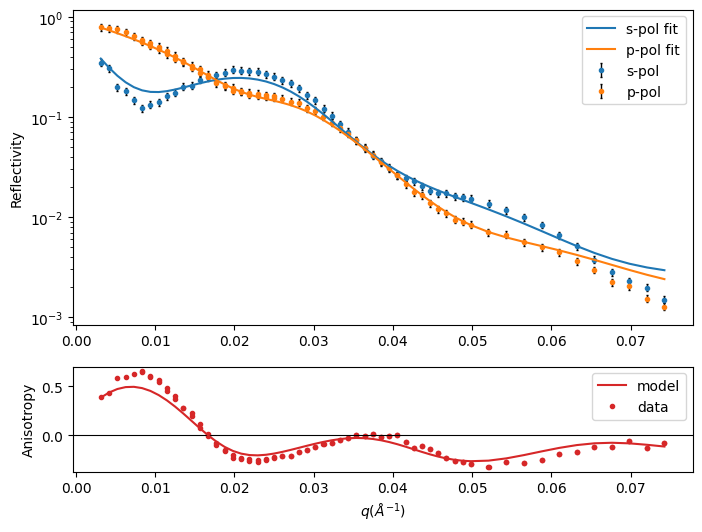

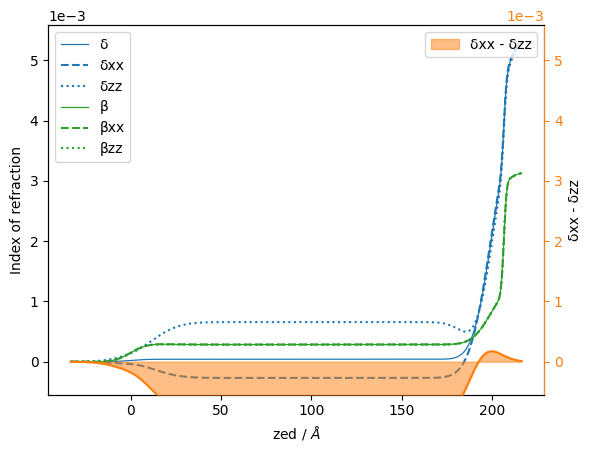

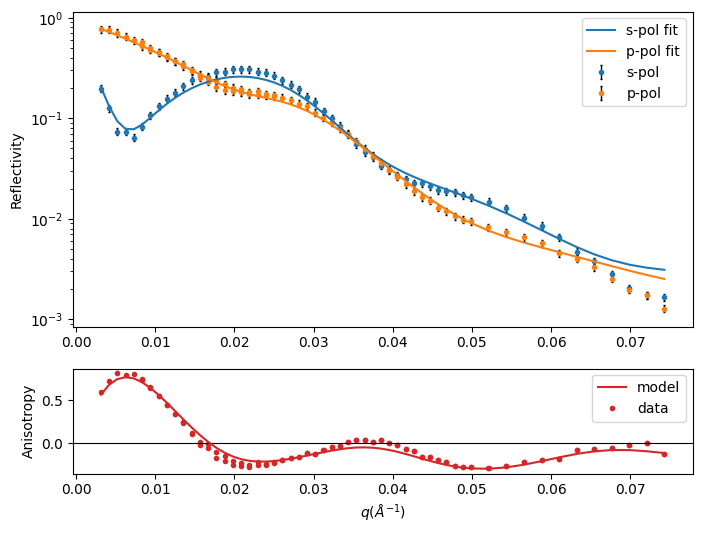

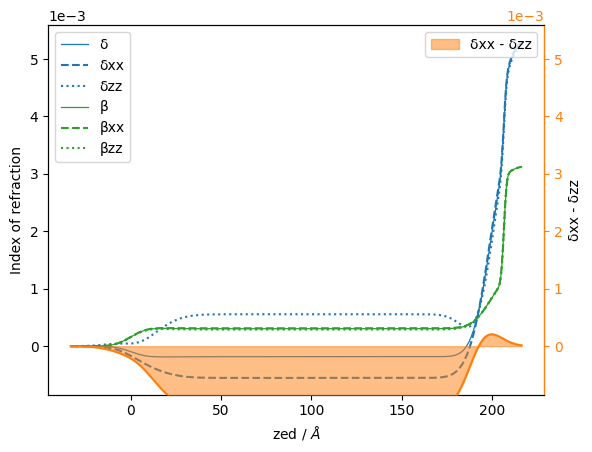

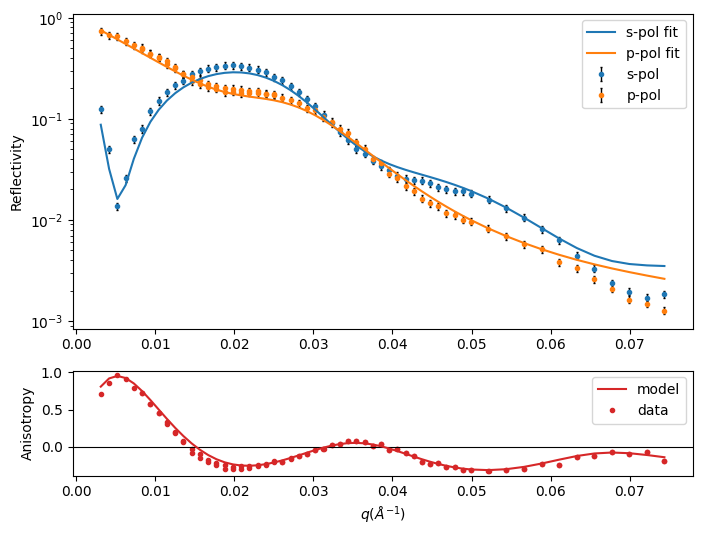

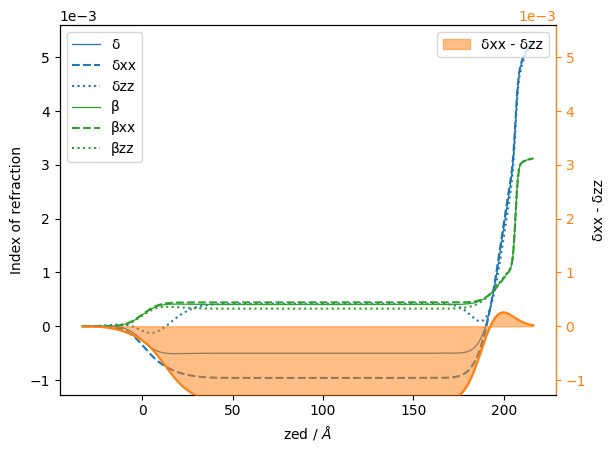

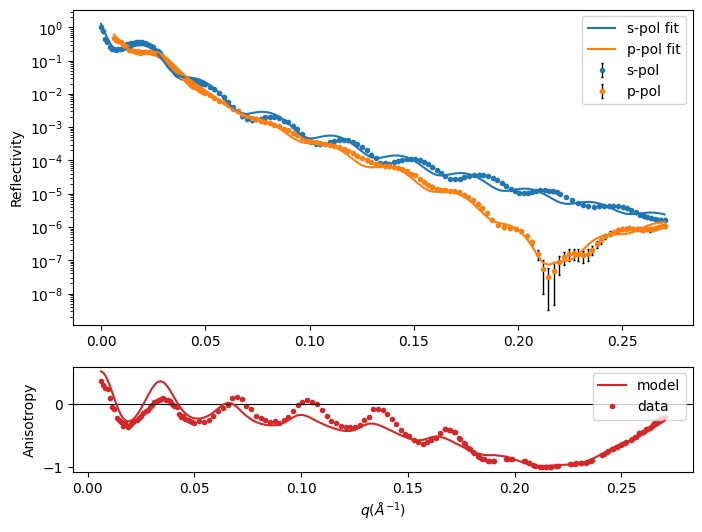

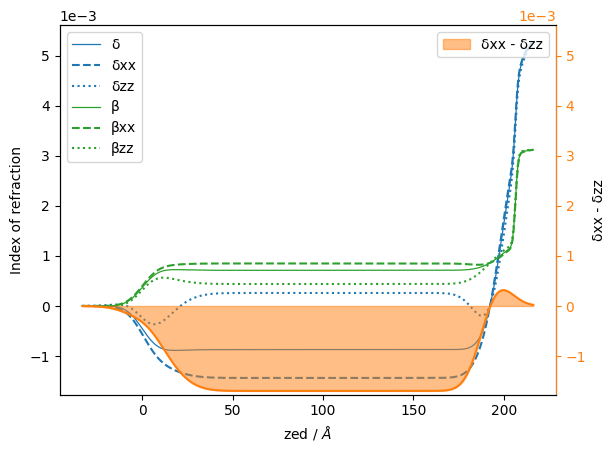

________________________________________________________________________________
Structure: Monolayer_283.7
reverse structure: False
________________________________________________________________________________
Parameters: 'Vacuum_283.7' 
________________________________________________________________________________
Parameters: 'Vacuum_283.7_slab'
<Parameter:'Vacuum_283.7_thick', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rough', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rho', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_energy_offset', value=0.00349378 +/- 1.99e-06, bounds=[-0.5, 0.5], constraint=<Parameter:'energy_offset', value=0.00349378 +/- 1.99e-06, bounds=[-0.5, 0.5]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'Surface_283.7_th

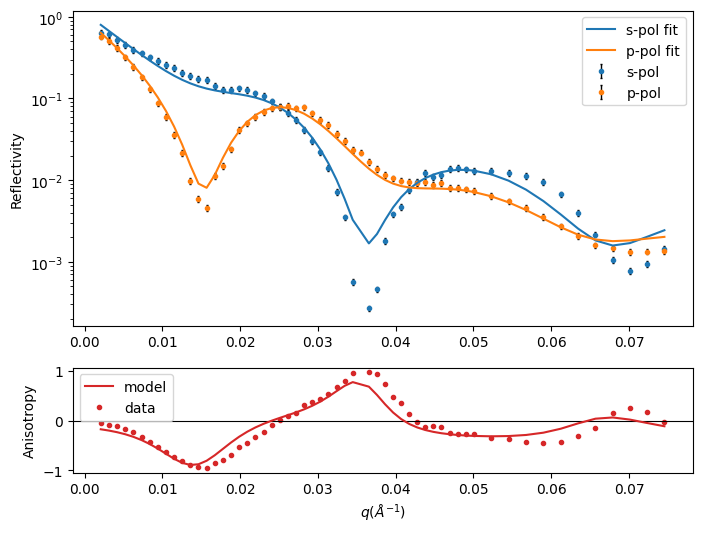

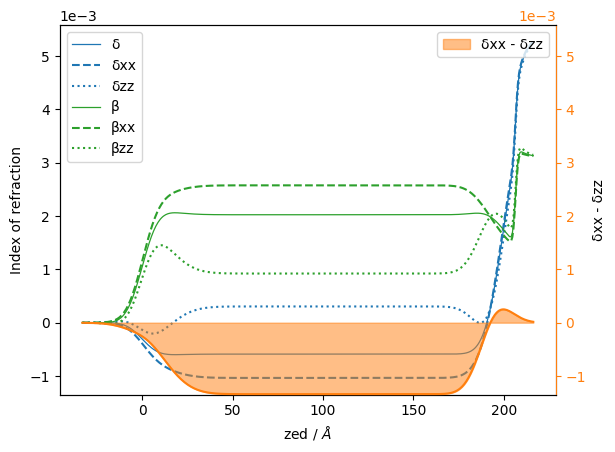

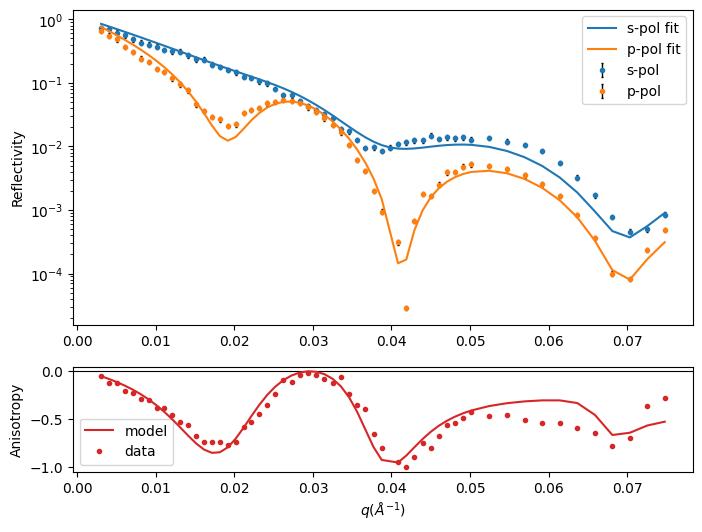

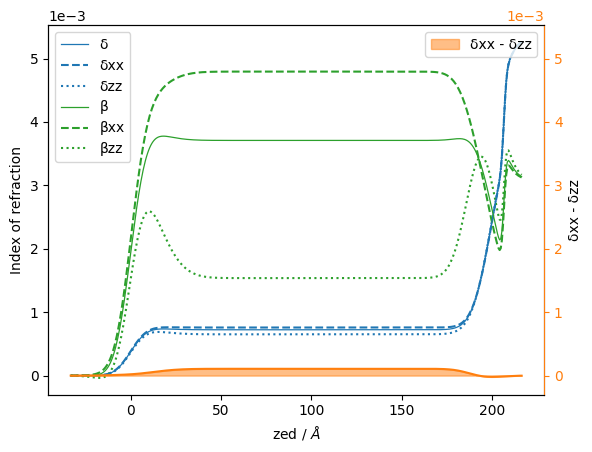

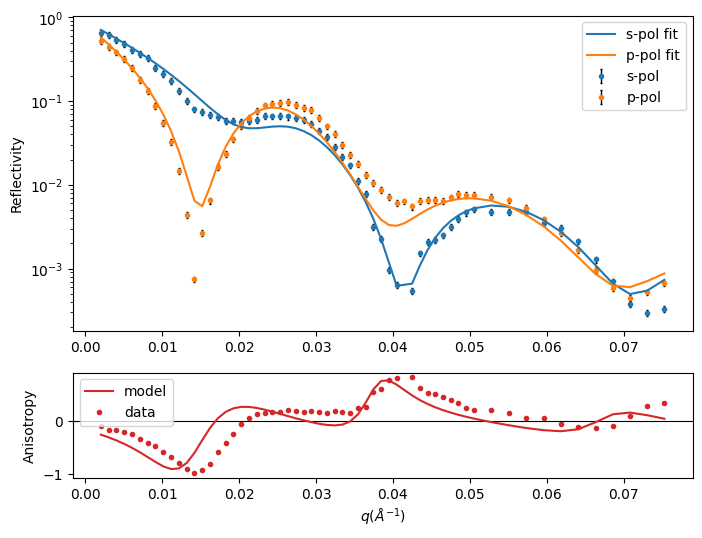

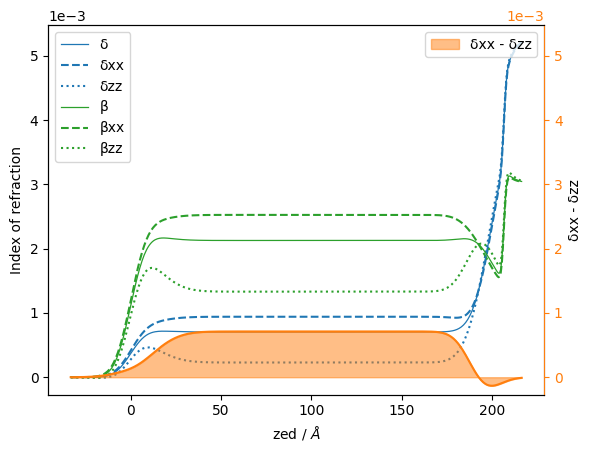

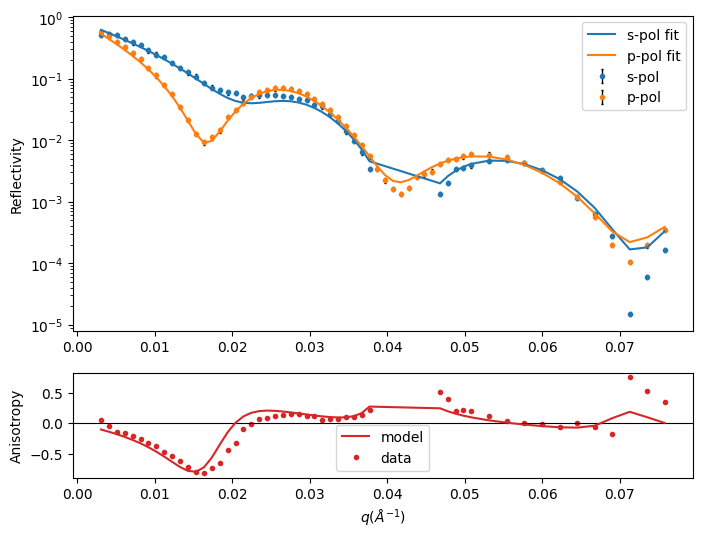

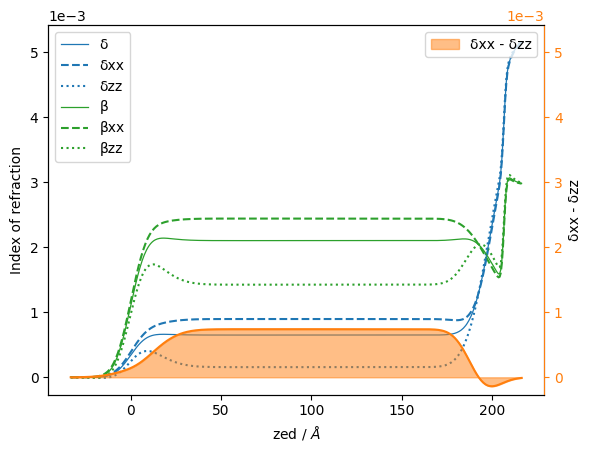

In [11]:
import matplotlib.pyplot as plt

for o in fitter.objective.objectives:
    if o.model.energy >= 283:
        o.plot()
        plt.show()
        o.model.structure.plot(difference=True)
        plt.show()
        if o.model.energy == 283.7:
            print(o.model.structure)

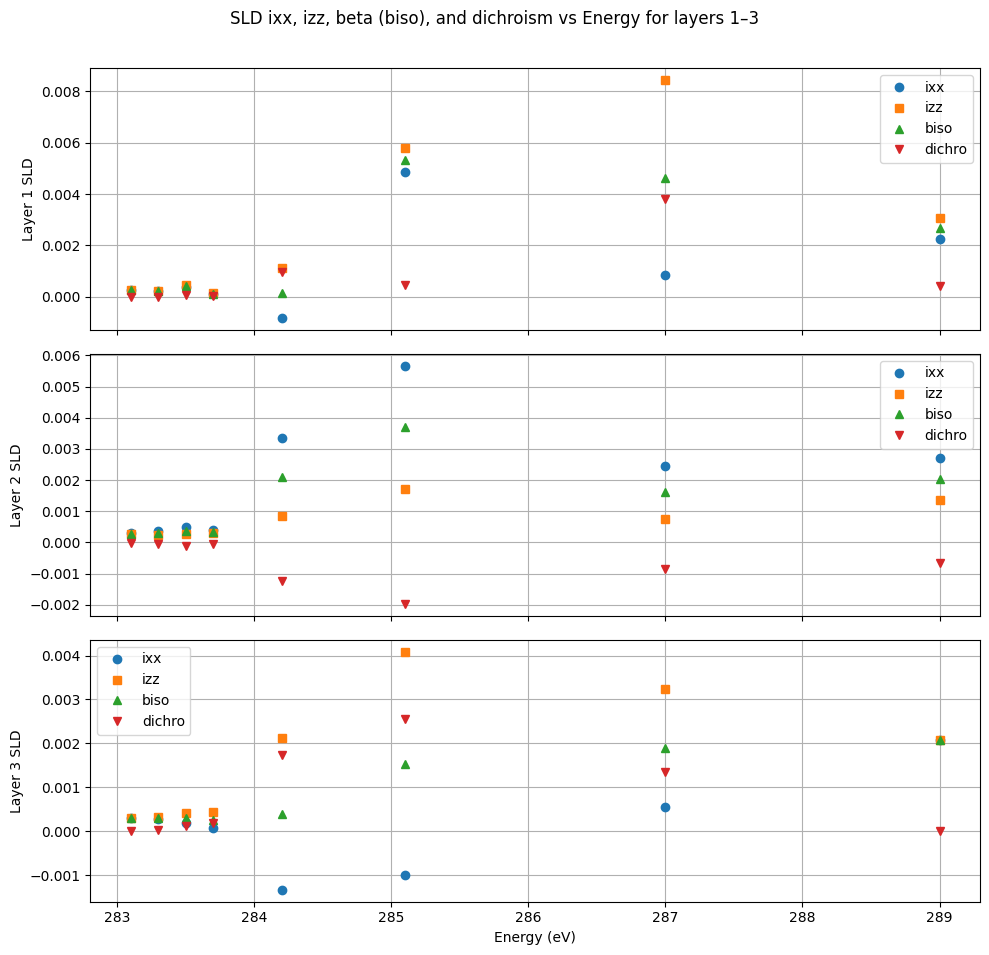

In [30]:
import pandas as pd

# Collect data into a pandas DataFrame for nicer plotting
data = []
for o in fitter.objective.objectives:
    if o.model.energy >= 283:
        row = {
            "energy": float(o.model.energy),
            "layer1_ixx": float(o.model.structure[1].sld.ixx.value),
            "layer1_izz": float(o.model.structure[1].sld.izz.value),
            "layer1_biso": float(o.model.structure[1].sld.beta.value),
            "layer1_dichro": float(o.model.structure[1].sld.dichroism.value),
            "layer2_ixx": float(o.model.structure[2].sld.ixx.value),
            "layer2_izz": float(o.model.structure[2].sld.izz.value),
            "layer2_biso": float(o.model.structure[2].sld.beta.value),
            "layer2_dichro": float(o.model.structure[2].sld.dichroism.value),
            "layer3_ixx": float(o.model.structure[3].sld.ixx.value),
            "layer3_izz": float(o.model.structure[3].sld.izz.value),
            "layer3_biso": float(o.model.structure[3].sld.beta.value),
            "layer3_dichro": float(o.model.structure[3].sld.dichroism.value),
        }
        data.append(row)

df = pd.DataFrame(data)

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

layer_labels = ["Layer 1", "Layer 2", "Layer 3"]
for idx, (ixx_col, izz_col, label) in enumerate(
    zip(
        ["layer1_ixx", "layer2_ixx", "layer3_ixx"],
        ["layer1_izz", "layer2_izz", "layer3_izz"],
        layer_labels,
    )
):
    axs[idx].plot(df["energy"], df[ixx_col], label="ixx", c="C0", marker="o", linestyle="")
    axs[idx].plot(df["energy"], df[izz_col], label="izz", c="C1", marker="s", linestyle="")
    axs[idx].plot(df["energy"], df[f"{'layer'+str(idx+1)}_biso"], label="biso", c="C2", marker="^", linestyle="")
    axs[idx].plot(df["energy"], df[f"{'layer'+str(idx+1)}_dichro"], label="dichro", c="C3", marker="v", linestyle="")
    axs[idx].set_ylabel(f"{label} SLD")
    axs[idx].legend()
    axs[idx].grid(True)

axs[2].set_xlabel("Energy (eV)")
fig.suptitle("SLD ixx, izz, beta (biso), and dichroism vs Energy for layers 1–3")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [31]:
df

,energy,layer1_ixx,layer1_izz,layer1_biso,layer1_dichro,layer2_ixx,layer2_izz,layer2_biso,layer2_dichro,layer3_ixx,layer3_izz,layer3_biso,layer3_dichro
0,283.1,0.000246,0.000246,0.000246,0.000000,0.000287,0.000261,0.000274,-0.000013,0.000309,0.000309,0.000309,0.000000
1,283.3,0.000237,0.000237,0.000237,0.000000,0.000350,0.000226,0.000288,-0.000062,0.000279,0.000332,0.000306,0.000027
2,283.5,0.000366,0.000467,0.000417,0.000051,0.000497,0.000252,0.000374,-0.000122,0.000184,0.000403,0.000293,0.000109
3,283.7,0.000090,0.000131,0.000110,0.000020,0.000396,0.000287,0.000341,-0.000054,0.000081,0.000429,0.000255,0.000174
4,284.2,-0.000831,0.001107,0.000138,0.000969,0.003352,0.000850,0.002101,-0.001251,-0.001337,0.002126,0.000394,0.001732
5,285.1,0.004874,0.005790,0.005332,0.000458,0.005663,0.001716,0.003689,-0.001973,-0.001005,0.004084,0.001539,0.002544
6,287.0,0.000835,0.008452,0.004643,0.003809,0.002465,0.000758,0.001612,-0.000853,0.000556,0.003239,0.001897,0.001341
7,289.0,0.002264,0.003074,0.002669,0.000405,0.002707,0.001374,0.002041,-0.000667,0.002080,0.002080,0.002080,0.000000


In [12]:
with open(models_root / "xrr/dft/dft_en_offset_new2.pkl", "wb") as f:
    pickle.dump(fitter.objective, f)